# Linear Regression

**Task**: Predict next-hour GK Volatility (`target_reg`)  
**Models**: Linear Regression from scratch (Normal Equation + Gradient Descent) and sklearn  
**Evaluation**: Loss, R², Confusion Matrix, Accuracy, Precision, Sensitivity, Specificity, TNR, F1, ROC & AUC, Performance Curves

---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# File paths
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

# compute regression metrics
def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

# results to CSV 
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

# plot & save confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Vol','High Vol'], yticklabels=['Low Vol','High Vol'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print('Libraries loaded')
print(f'BASE_DIR    : {BASE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'PLOTS_DIR   : {PLOTS_DIR}')


Libraries loaded
BASE_DIR    : d:\ML\Project-Including model training\cryptoflow
RESULTS_DIR : d:\ML\Project-Including model training\cryptoflow\results
PLOTS_DIR   : d:\ML\Project-Including model training\cryptoflow\plots


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')


Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.006115      0.003886
std        0.005756      0.003113
min        0.000000      0.000229
25%        0.002852      0.001998
50%        0.004590      0.003076
75%        0.007497      0.004795
max        0.213448      0.085401


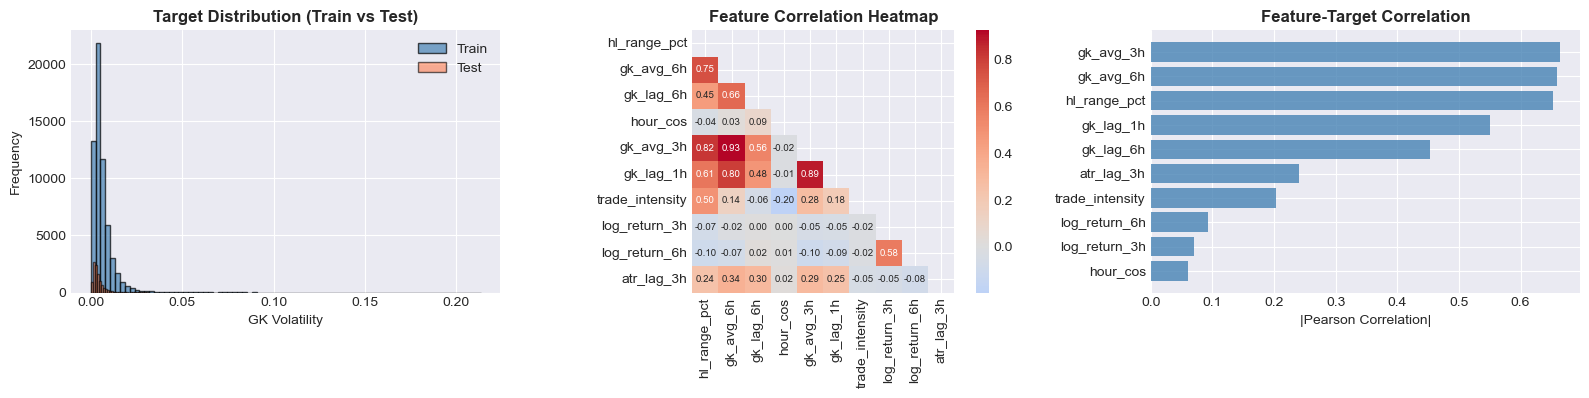

In [3]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='steelblue', edgecolor='black', label='Train')
axes[0].hist(y_test,  bins=80, alpha=0.6, color='coral',     edgecolor='black', label='Test')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Train vs Test)', fontweight='bold')
axes[0].legend()

df_feat = pd.DataFrame(X_train, columns=feature_cols)
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, square=True)
axes[1].set_title('Feature Correlation Heatmap', fontweight='bold')

feat_target_corr = df_feat.corrwith(pd.Series(y_train)).abs().sort_values(ascending=True)
axes[2].barh(feat_target_corr.index, feat_target_corr.values, color='steelblue', alpha=0.8)
axes[2].set_xlabel('|Pearson Correlation|')
axes[2].set_title('Feature-Target Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Linear Regression — From Scratch

**Normal Equation**: $\hat{w} = (X^TX)^{-1}X^Ty$  
**Gradient Descent**: mini-batch weight updates

In [4]:
class LinearRegressionScratch:
    """Linear Regression from scratch. Supports Normal Equation and Mini-batch Gradient Descent."""
    def __init__(self, method='normal', learning_rate=0.005,
                 n_epochs=100, batch_size=256, verbose=True):
        self.method       = method
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.verbose      = verbose
        self.weights      = None
        self.bias         = None
        self.train_losses = []
        self.val_losses   = []

    def fit(self, X, y, X_val=None, y_val=None):
        n, p = X.shape
        if self.method == 'normal':
            Xb = np.hstack([np.ones((n, 1)), X])
            theta, _, _, _ = np.linalg.lstsq(Xb, y, rcond=None)
            self.bias    = float(theta[0])
            self.weights = theta[1:]
            self.train_losses = [float(np.mean((self.predict(X) - y) ** 2))]
        elif self.method == 'gradient_descent':
            self.weights = np.zeros(p)
            self.bias    = 0.0
            self.train_losses = []
            self.val_losses   = []
            for epoch in range(self.n_epochs):
                idx = np.random.permutation(n)
                Xs, ys = X[idx], y[idx]
                for start in range(0, n, self.batch_size):
                    Xb = Xs[start:start+self.batch_size]
                    yb = ys[start:start+self.batch_size]
                    nb = len(yb)
                    err = Xb @ self.weights + self.bias - yb
                    self.weights -= self.lr * (2/nb) * (Xb.T @ err)
                    self.bias    -= self.lr * (2/nb) * err.sum()
                train_mse = float(np.mean((self.predict(X) - y) ** 2))
                self.train_losses.append(train_mse)
                if X_val is not None:
                    self.val_losses.append(float(np.mean((self.predict(X_val) - y_val) ** 2)))
                if self.verbose and (epoch + 1) % 10 == 0:
                    msg = f'  Epoch {epoch+1:3d}/{self.n_epochs} — Train MSE: {train_mse:.8f}'
                    if X_val is not None:
                        msg += f' | Val MSE: {self.val_losses[-1]:.8f}'
                    print(msg)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def get_coefficients(self, feature_names=None):
        names = feature_names or [f'x{i}' for i in range(len(self.weights))]
        return pd.Series(self.weights, index=names).sort_values(key=abs, ascending=False)

print('LinearRegressionScratch defined')


LinearRegressionScratch defined


In [5]:
# Normal Equation
lr_normal = LinearRegressionScratch(method='normal')
lr_normal.fit(X_train, y_train)
y_pred_train_normal = lr_normal.predict(X_train)
y_pred_test_normal  = lr_normal.predict(X_test)
print('Normal Equation done')


Normal Equation done


In [6]:
# Gradient Descent
lr_gd = LinearRegressionScratch(method='gradient_descent',
                                 learning_rate=0.005, n_epochs=100,
                                 batch_size=256, verbose=True)
lr_gd.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
y_pred_train_gd = lr_gd.predict(X_train)
y_pred_test_gd  = lr_gd.predict(X_test)
print('Gradient Descent done')


  Epoch  10/100 — Train MSE: 0.00001805 | Val MSE: 0.00000798
  Epoch  20/100 — Train MSE: 0.00001802 | Val MSE: 0.00000801
  Epoch  30/100 — Train MSE: 0.00001806 | Val MSE: 0.00000799
  Epoch  40/100 — Train MSE: 0.00001801 | Val MSE: 0.00000798
  Epoch  50/100 — Train MSE: 0.00001802 | Val MSE: 0.00000804
  Epoch  60/100 — Train MSE: 0.00001803 | Val MSE: 0.00000798
  Epoch  70/100 — Train MSE: 0.00001805 | Val MSE: 0.00000795
  Epoch  80/100 — Train MSE: 0.00001801 | Val MSE: 0.00000790
  Epoch  90/100 — Train MSE: 0.00001801 | Val MSE: 0.00000804
  Epoch 100/100 — Train MSE: 0.00001806 | Val MSE: 0.00000801
Gradient Descent done


---
## 4. Linear Regression — sklearn

In [7]:
lr_sk = LinearRegression()
lr_sk.fit(X_train, y_train)
y_pred_train_sk = lr_sk.predict(X_train)
y_pred_test_sk  = lr_sk.predict(X_test)
print('Linear Regression (sklearn) done')

print('\nScratch vs sklearn R² comparison:')
print(f'  Normal Eq : {r2_score(y_test, y_pred_test_normal):.4f}')
print(f'  GD        : {r2_score(y_test, y_pred_test_gd):.4f}')
print(f'  sklearn   : {r2_score(y_test, y_pred_test_sk):.4f}')


Linear Regression (sklearn) done

Scratch vs sklearn R² comparison:
  Normal Eq : 0.3683
  GD        : 0.3316
  sklearn   : 0.3683


---
## 5. Loss (MSE / RMSE / MAE / R² / MAPE)

In [8]:
models_pred = {
    'Linear Normal (scratch)': (y_pred_train_normal, y_pred_test_normal),
    'Linear GD (scratch)'    : (y_pred_train_gd,     y_pred_test_gd),
    'Linear sklearn'         : (y_pred_train_sk,     y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

# Save each model's metrics to results CSV
for name, m in all_metrics.items():
    save_results(m)



  Linear Normal (scratch)
  MSE     : 0.00000612
  RMSE    : 0.00247410
  MAE     : 0.00161493
  R²      : 0.3683
  MAPE(%) : 56.9687

  Linear GD (scratch)
  MSE     : 0.00000648
  RMSE    : 0.00254509
  MAE     : 0.00175385
  R²      : 0.3316
  MAPE(%) : 66.3923

  Linear sklearn
  MSE     : 0.00000612
  RMSE    : 0.00247410
  MAE     : 0.00161493
  R²      : 0.3683
  MAPE(%) : 56.9687
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
Results saved → d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv


---
## 6. R² Score

=== R² Score Summary ===
Linear Normal (scratch)    Train R²: 0.502498  |  Test R²: 0.368318
Linear GD (scratch)        Train R²: 0.500411  |  Test R²: 0.331551
Linear sklearn             Train R²: 0.502498  |  Test R²: 0.368318


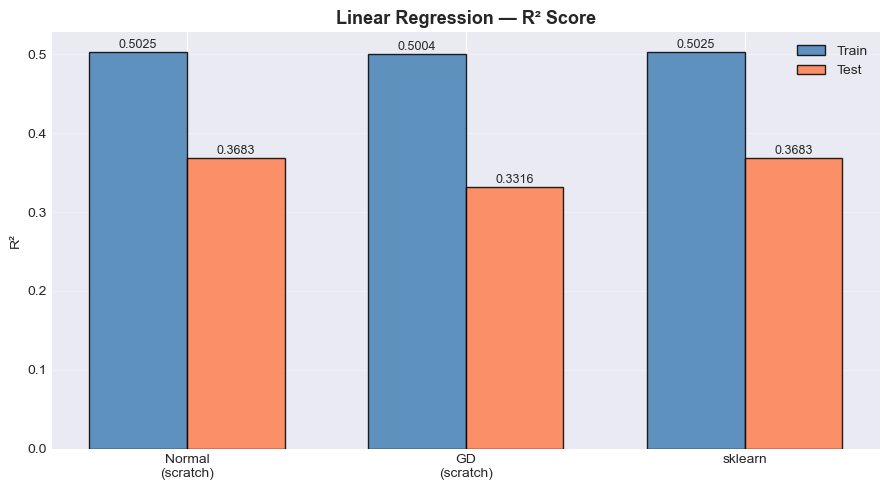

In [9]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'{name:25s}  Train R²: {r2_score(y_train, y_tr_p):.6f}  |  Test R²: {r2_score(y_test, y_te_p):.6f}')

short = ['Normal\n(scratch)', 'GD\n(scratch)', 'sklearn']
r2_train_vals = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_test_vals  = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, r2_train_vals, w, label='Train', color='steelblue', alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, r2_test_vals,  w, label='Test',  color='coral',     alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('Linear Regression — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b, vv) for bars, vs in [(b1,r2_train_vals),(b2,r2_test_vals)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Performance Curves (Loss Plots)

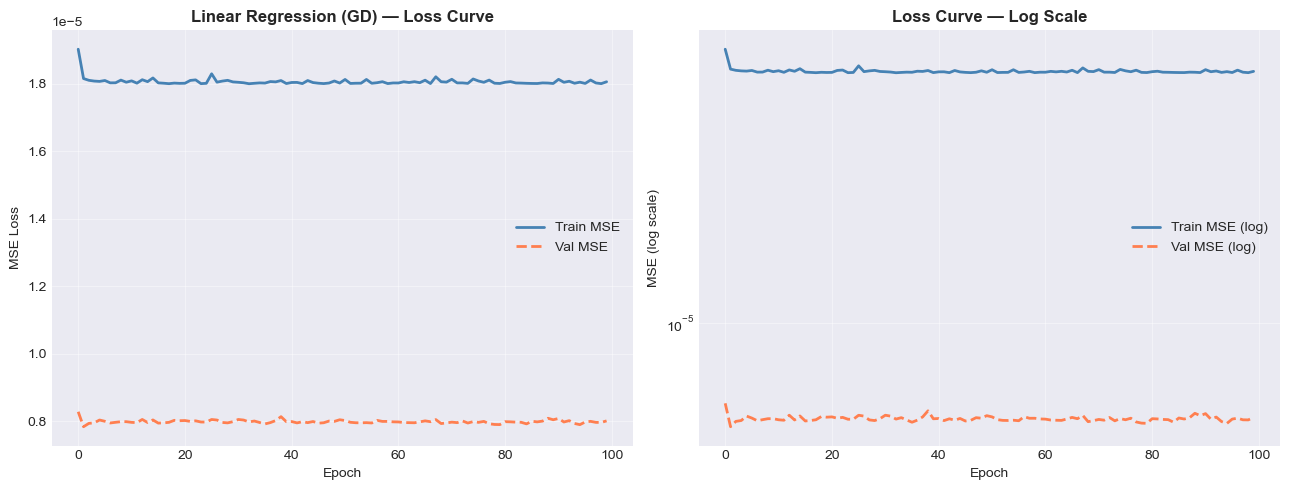

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lr_gd.train_losses, color='steelblue', lw=2, label='Train MSE')
if lr_gd.val_losses:
    axes[0].plot(lr_gd.val_losses, color='coral', lw=2, ls='--', label='Val MSE')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Linear Regression (GD) — Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].semilogy(lr_gd.train_losses, color='steelblue', lw=2, label='Train MSE (log)')
if lr_gd.val_losses:
    axes[1].semilogy(lr_gd.val_losses, color='coral', lw=2, ls='--', label='Val MSE (log)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log scale)')
axes[1].set_title('Loss Curve — Log Scale', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Binarise Predictions for Classification Metrics

Binarise at the **median GK volatility**:
- 1 = High Volatility (>= median)
- 0 = Low Volatility (< median)

In [11]:
threshold = float(np.median(y_test))
print(f'Binarisation threshold (median GK): {threshold:.6f}')
y_true_bin = (y_test >= threshold).astype(int)

bin_results = {}
for name, (_, y_te_p) in models_pred.items():
    y_pred_bin = (y_te_p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    sens = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true_bin, y_te_p)
    roc_auc = auc(fpr, tpr)
    bin_results[name] = {
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Sensitivity(TPR)': round(sens,4), 'Specificity(TNR)': round(spec,4),
        'True Negative Rate': round(spec,4), 'F1-Score': round(f1,4),
        'AUC': round(roc_auc,4), '_fpr': fpr, '_tpr': tpr
    }

df_bin = pd.DataFrame({k:{kk:vv for kk,vv in v.items() if not kk.startswith('_')}
                        for k,v in bin_results.items()}).T
print('\n=== Classification Metrics (Binarised from Regression Output) ===')
print(df_bin.to_string())


Binarisation threshold (median GK): 0.003076

=== Classification Metrics (Binarised from Regression Output) ===
                             TP      TN      FP     FN  Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  True Negative Rate  F1-Score     AUC
Linear Normal (scratch)  4894.0  2321.0  2996.0  424.0    0.6784     0.6203            0.9203            0.4365              0.4365    0.7411  0.8378
Linear GD (scratch)      5042.0  1518.0  3799.0  276.0    0.6168     0.5703            0.9481            0.2855              0.2855    0.7122  0.8285
Linear sklearn           4894.0  2321.0  2996.0  424.0    0.6784     0.6203            0.9203            0.4365              0.4365    0.7411  0.8378


---
## 9. Confusion Matrix

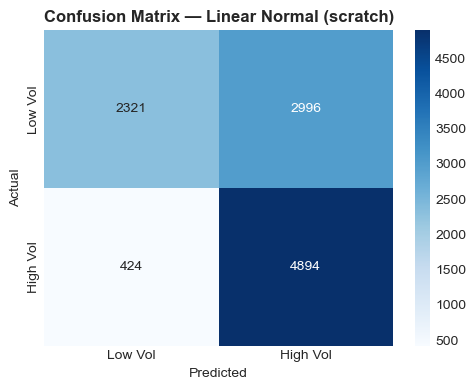

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_lr_Linear_Normal_scratch.png


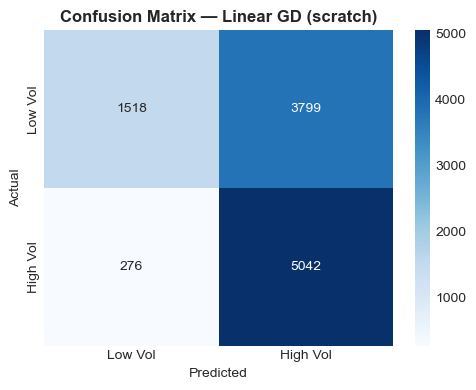

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_lr_Linear_GD_scratch.png


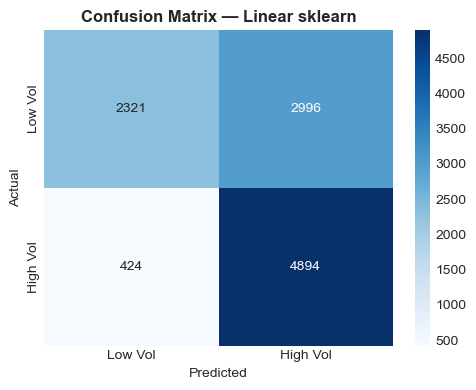

Saved: d:\ML\Project-Including model training\cryptoflow\plots\cm_lr_Linear_sklearn.png


In [12]:
for name, res in bin_results.items():
    y_pred_bin = (models_pred[name][1] >= threshold).astype(int)
    safe_name  = name.replace(' ', '_').replace('(', '').replace(')', '').replace('=','')
    plot_confusion_matrix(y_true_bin, y_pred_bin, name,
                          os.path.join(PLOTS_DIR, f'cm_lr_{safe_name}.png'))


---
## 10. ROC Curve & AUC

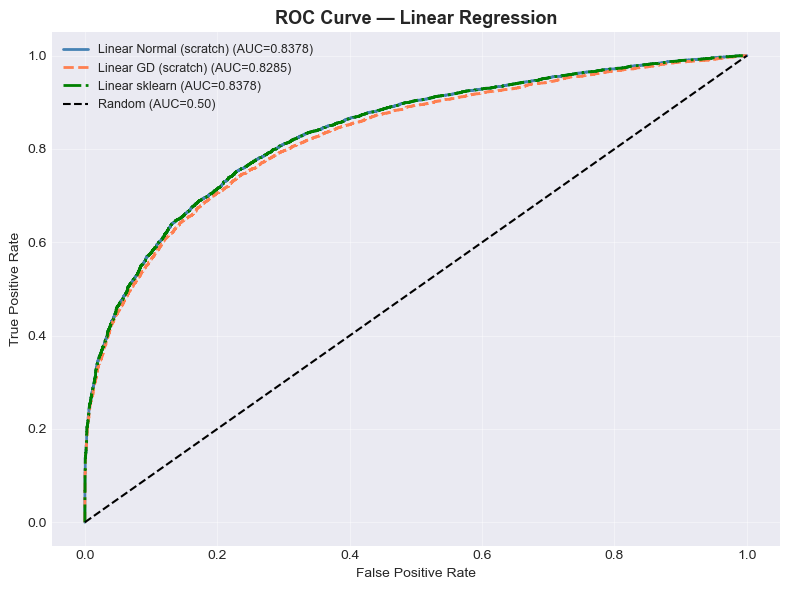

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'coral', 'green']
styles = ['-', '--', '-.']

for (name, res), color, ls in zip(bin_results.items(), colors, styles):
    ax.plot(res['_fpr'], res['_tpr'], color=color, lw=2, ls=ls,
            label=f'{name} (AUC={res["AUC"]:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Linear Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Precision / Sensitivity / Specificity / TNR / F1 Charts

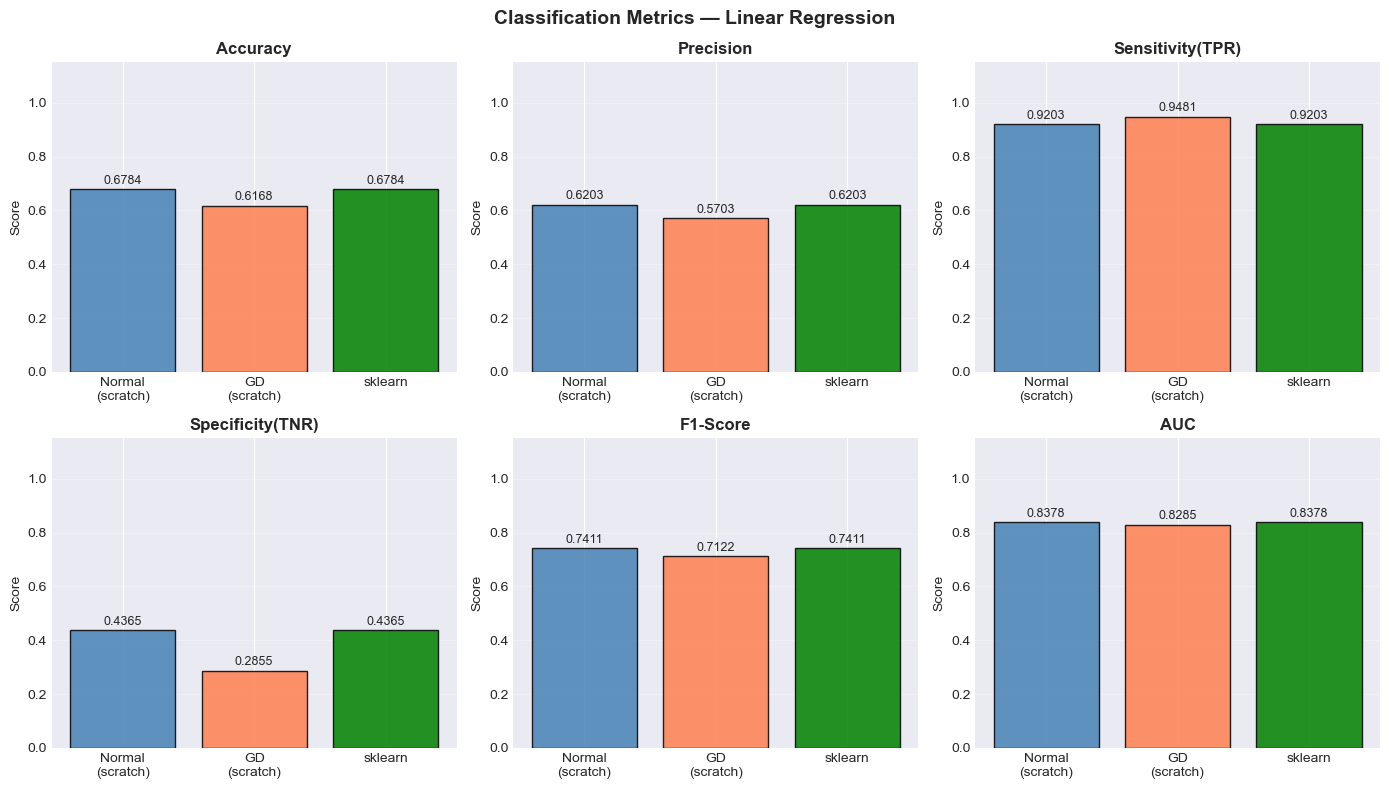

In [14]:
metrics_list = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
short = ['Normal\n(scratch)', 'GD\n(scratch)', 'sklearn']
palette = ['steelblue','coral','green']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_list):
    vals = [bin_results[m][metric] for m in bin_results]
    bars = ax.bar(short, vals, color=palette, edgecolor='black', alpha=0.85)
    ax.set_ylim(0, 1.15); ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Classification Metrics — Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_classification_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Actual vs Predicted & Residual Analysis

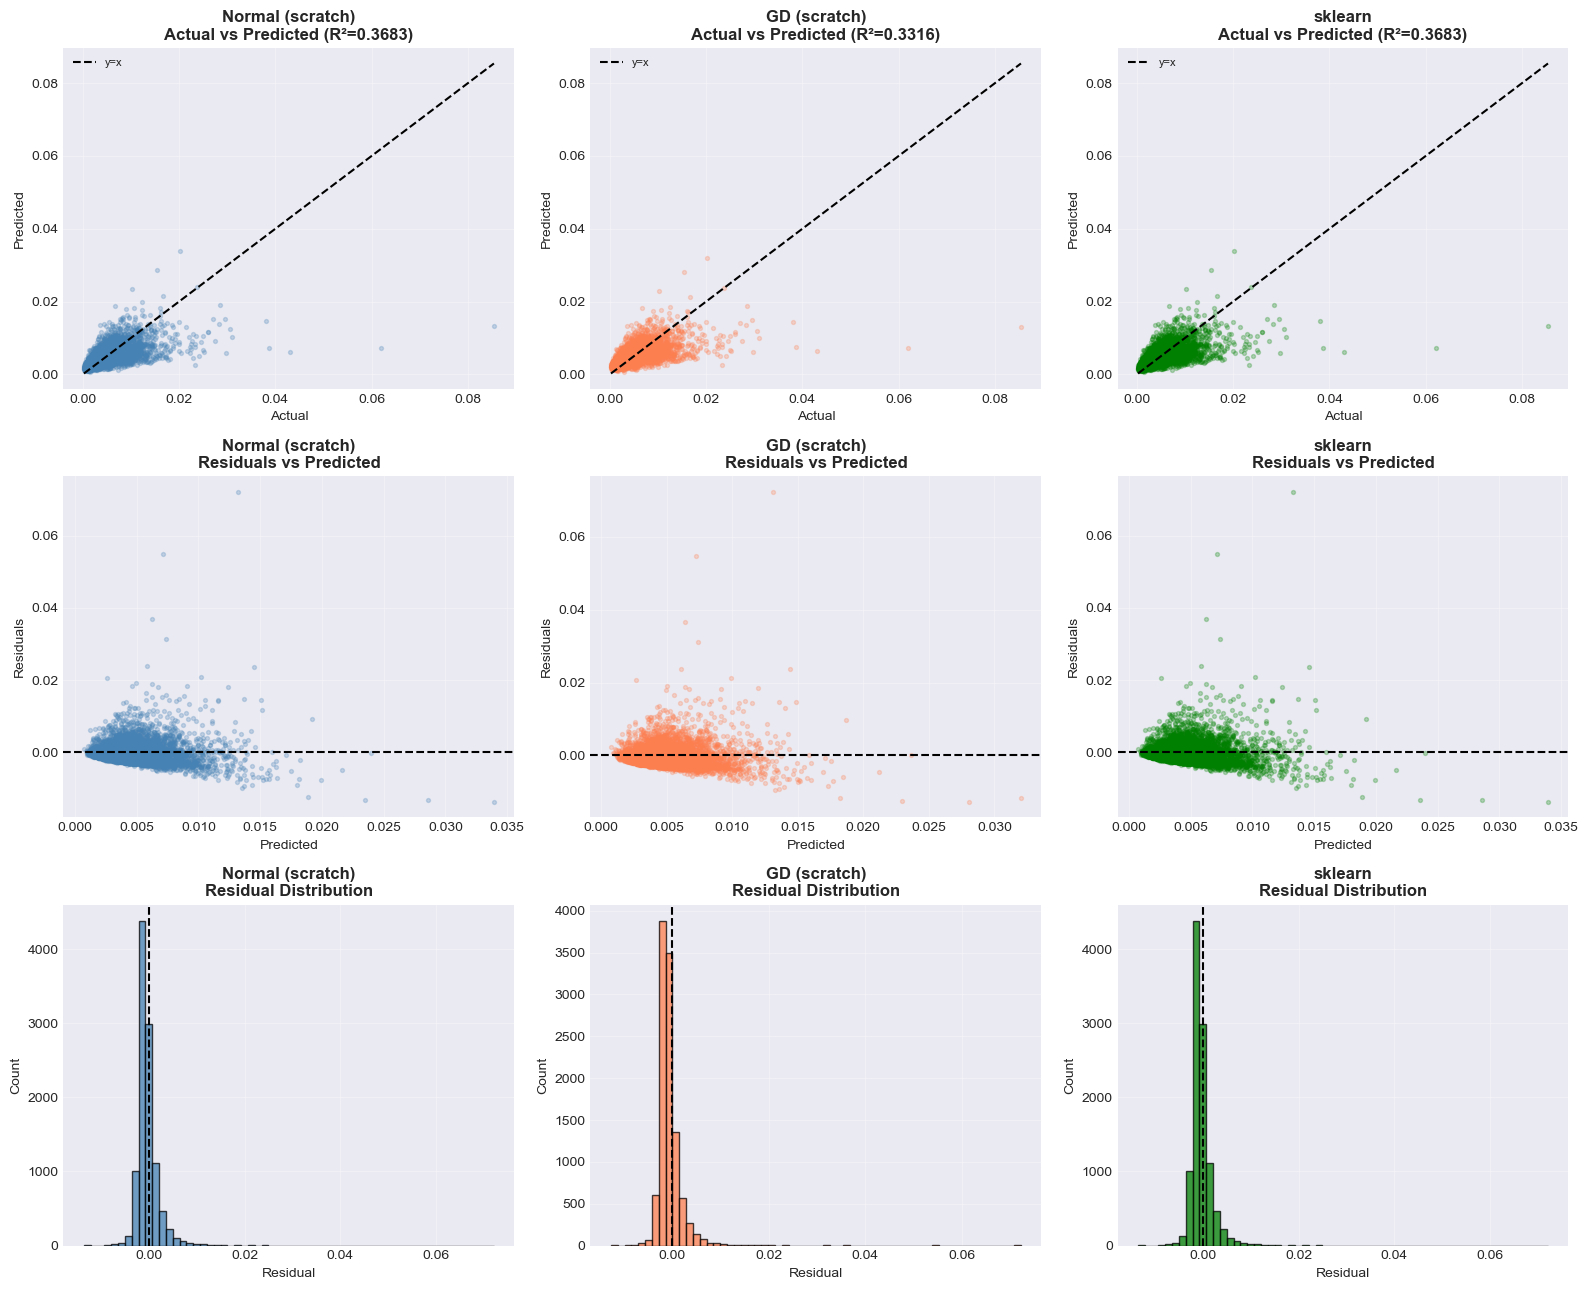

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
pred_list = [
    ('Normal (scratch)', y_pred_test_normal, 'steelblue'),
    ('GD (scratch)',     y_pred_test_gd,     'coral'),
    ('sklearn',          y_pred_test_sk,     'green'),
]

for col, (title, y_pred, color) in enumerate(pred_list):
    axes[0,col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[0,col].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='y=x')
    r2 = r2_score(y_test, y_pred)
    axes[0,col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0,col].set_xlabel('Actual'); axes[0,col].set_ylabel('Predicted')
    axes[0,col].legend(fontsize=8); axes[0,col].grid(alpha=0.3)

    res = y_test - y_pred
    axes[1,col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1,col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1,col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1,col].set_xlabel('Predicted'); axes[1,col].set_ylabel('Residuals')
    axes[1,col].grid(alpha=0.3)

    axes[2,col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2,col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2,col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2,col].set_xlabel('Residual'); axes[2,col].set_ylabel('Count')
    axes[2,col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 13. Time-Series Prediction Plot

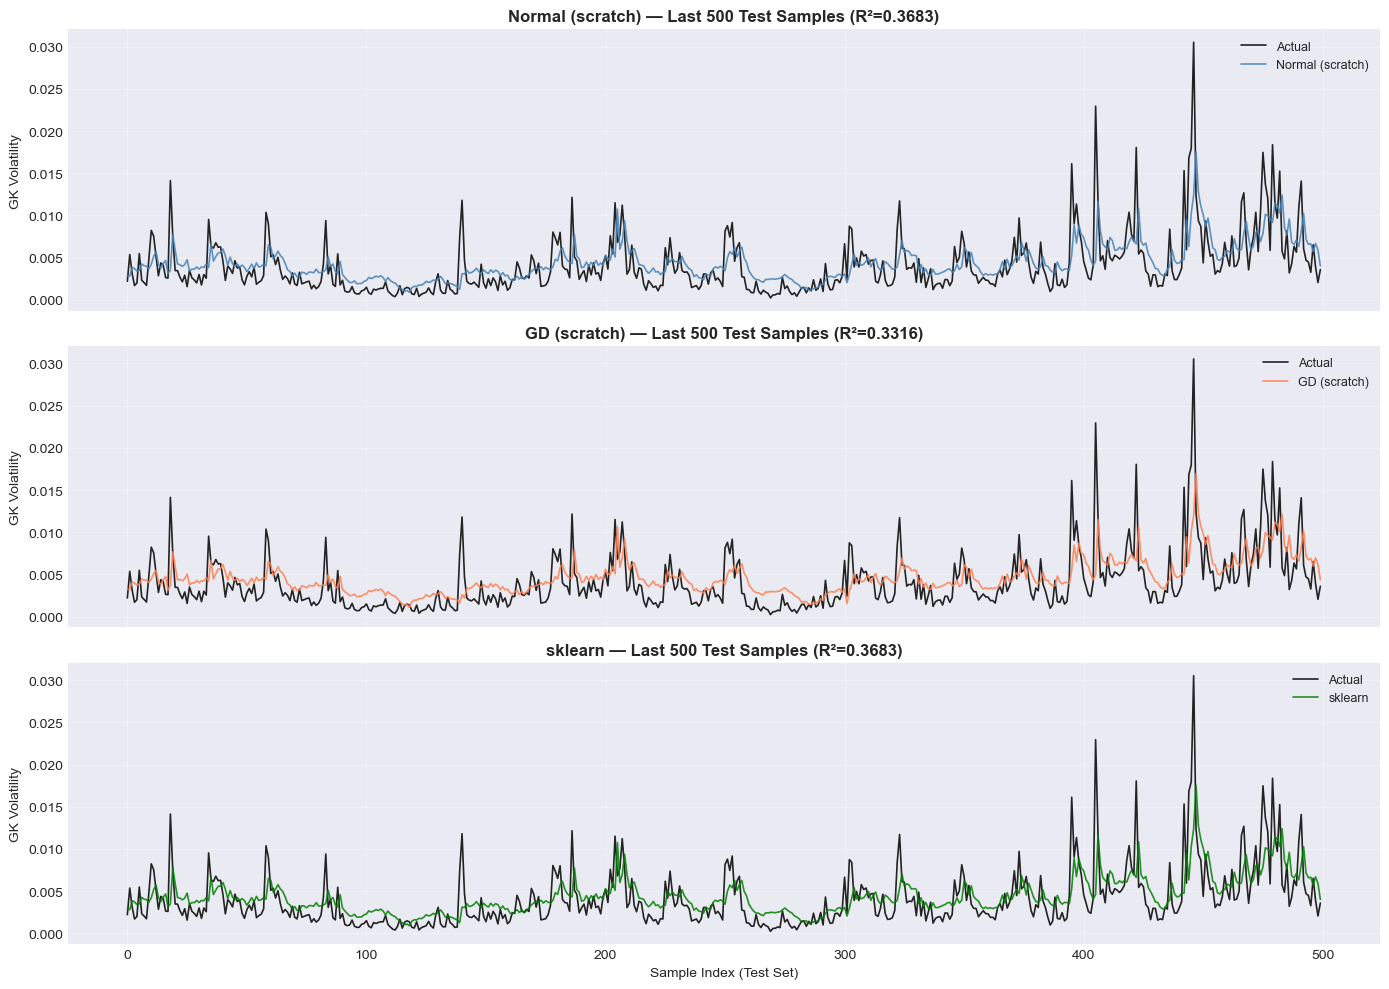

In [16]:
n_plot = 500
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:], color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:], color=color,   lw=1.2, label=title, alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Coefficient Analysis

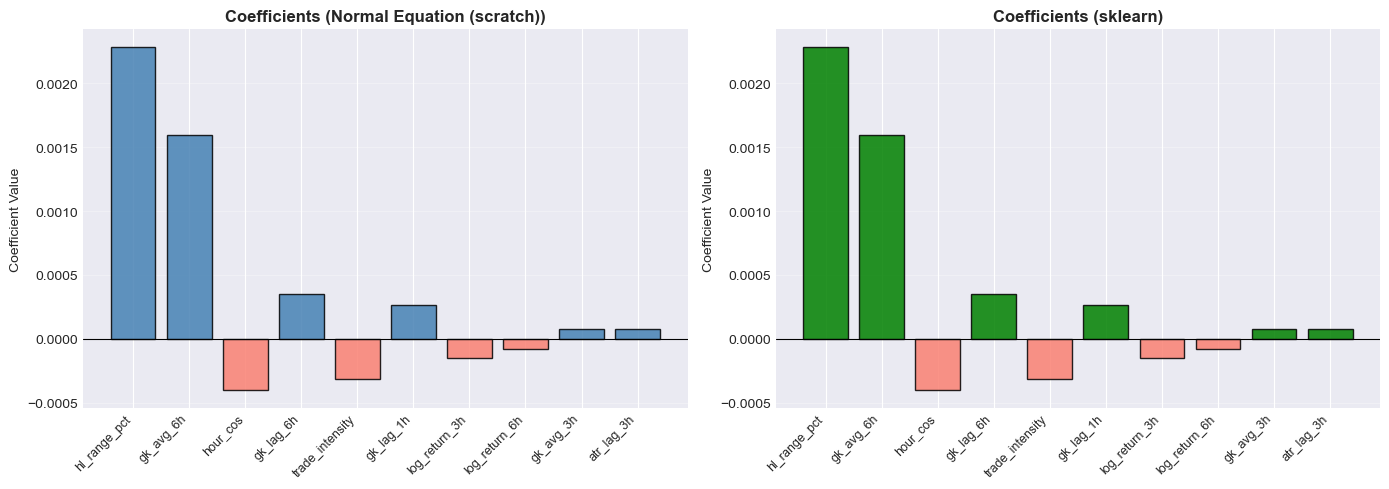

In [17]:
coefs_normal = lr_normal.get_coefficients(feature_cols)
coefs_sk     = pd.Series(lr_sk.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coefs, title, color in [
    (axes[0], coefs_normal, 'Normal Equation (scratch)', 'steelblue'),
    (axes[1], coefs_sk,     'sklearn',                   'green')
]:
    bar_colors = [color if v > 0 else 'salmon' for v in coefs.values]
    ax.bar(coefs.index, coefs.values, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticklabels(coefs.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Coefficient Value')
    ax.set_title(f'Coefficients ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'lr_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Save & Load Models

In [18]:
with open(os.path.join(MODELS_DIR, 'lr_normal_scratch.pkl'), 'wb') as f: pickle.dump(lr_normal, f)
with open(os.path.join(MODELS_DIR, 'lr_gd_scratch.pkl'),    'wb') as f: pickle.dump(lr_gd,     f)
with open(os.path.join(MODELS_DIR, 'lr_sklearn.pkl'),        'wb') as f: pickle.dump(lr_sk,     f)
with open(os.path.join(MODELS_DIR, 'lr_scaler.pkl'),         'wb') as f: pickle.dump(scaler,    f)
print('Models saved to:', MODELS_DIR)

with open(os.path.join(MODELS_DIR, 'lr_normal_scratch.pkl'), 'rb') as f: m = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'lr_scaler.pkl'),         'rb') as f: s = pickle.load(f)
X_new = s.transform(test[feature_cols].values)
print(f'Load verification — R²: {r2_score(y_test, m.predict(X_new)):.6f}  OK')


Models saved to: d:\ML\Project-Including model training\cryptoflow\models
Load verification — R²: 0.368318  OK


---
## 16. Final Summary

In [19]:
print('='*65)
print('  LINEAR REGRESSION — FINAL SUMMARY')
print('='*65)
print('\n--- Regression Metrics (Test Set) ---')
for name, (_, y_te) in models_pred.items():
    m = all_metrics[name]
    print(f'  {name:25s}  MSE={m["mse"]:.6e}  RMSE={m["rmse"]:.6e}  R²={m["r2"]:.4f}')

print('\n--- Classification Metrics (Binarised at median GK) ---')
cols = ['Accuracy','Precision','Sensitivity(TPR)','Specificity(TNR)','F1-Score','AUC']
print(df_bin[cols].to_string())
print('='*65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')


  LINEAR REGRESSION — FINAL SUMMARY

--- Regression Metrics (Test Set) ---
  Linear Normal (scratch)    MSE=6.120000e-06  RMSE=2.474100e-03  R²=0.3683
  Linear GD (scratch)        MSE=6.480000e-06  RMSE=2.545090e-03  R²=0.3316
  Linear sklearn             MSE=6.120000e-06  RMSE=2.474100e-03  R²=0.3683

--- Classification Metrics (Binarised at median GK) ---
                         Accuracy  Precision  Sensitivity(TPR)  Specificity(TNR)  F1-Score     AUC
Linear Normal (scratch)    0.6784     0.6203            0.9203            0.4365    0.7411  0.8378
Linear GD (scratch)        0.6168     0.5703            0.9481            0.2855    0.7122  0.8285
Linear sklearn             0.6784     0.6203            0.9203            0.4365    0.7411  0.8378

All plots saved to : d:\ML\Project-Including model training\cryptoflow\plots
Results saved to   : d:\ML\Project-Including model training\cryptoflow\results\regression_results.csv
